# Red Butte SNOTEL Analysis (Fort Douglas)

This notebook reproduces the SNOTEL workflow for **USGS 10172200** (Red Butte Creek at Fort Douglas, UT).

It includes robust fallbacks for this site:
- if NLDI basin delineation is unavailable, it uses a buffered AOI around the gage
- it skips stations that do not contain valid values for the selected WY + DOI

In [14]:
from pathlib import Path
import datetime
import warnings
import importlib

import geopandas as gpd
import numpy as np
import pandas as pd
from pynhd import NLDI

from supporting_scripts import SNOTEL_Analyzer, dataprocessing, getData
importlib.reload(SNOTEL_Analyzer)

warnings.filterwarnings("ignore")

USGS_GAGE_ID = "10172200"  # Red Butte Creek at Fort Douglas, UT
WY = 2019
DOI = "04-01"
WATERSHED = "Red Butte"
AOI_NAME = "Above Fort Douglas"
MAX_SITES = 4
BUFFER_KM_IF_NO_BASIN = 20

data_dir = Path("files/SNOTEL")
data_dir.mkdir(parents=True, exist_ok=True)

In [8]:
def to_date_string(value):
    if isinstance(value, str):
        return value
    return datetime.datetime.strftime(value, "%Y-%m-%d")


def get_state_abbr_from_code(code, state_name):
    return "UT"

## 1) Build AOI and find candidate stations

In [3]:
stations = gpd.read_file(
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
).set_index("code")
stations = stations[stations["csvData"] == True].copy()

nldi = NLDI()
site_feature = nldi.getfeature_byid("nwissite", f"USGS-{USGS_GAGE_ID}")

try:
    basin = nldi.get_basins(USGS_GAGE_ID)
    aoi = basin
    print("Using NLDI basin polygon.")
except Exception:
    print(f"NLDI basin unavailable for {USGS_GAGE_ID}. Using {BUFFER_KM_IF_NO_BASIN} km buffer around gage.")
    aoi = site_feature.to_crs(5070).copy()
    aoi["geometry"] = aoi.geometry.buffer(BUFFER_KM_IF_NO_BASIN * 1000)
    aoi = aoi.to_crs(stations.crs)

gdf_in_aoi = stations[stations.geometry.within(aoi.geometry.iloc[0])].copy()

if gdf_in_aoi.empty:
    print("No stations found in AOI polygon. Falling back to nearest stations.")
    site_proj = site_feature.to_crs(5070)
    stations_proj = stations.to_crs(5070)
    stations_proj["dist_m"] = stations_proj.geometry.distance(site_proj.geometry.iloc[0])
    gdf_in_aoi = stations_proj.nsmallest(MAX_SITES, "dist_m").to_crs(stations.crs)

gdf_in_aoi = gdf_in_aoi.reset_index(drop=False)
gdf_in_aoi["code"] = gdf_in_aoi["code"].astype(str).str.split("_").str[0]
gdf_in_aoi["beginDate"] = [to_date_string(value) for value in gdf_in_aoi["beginDate"]]
gdf_in_aoi["endDate"] = [to_date_string(value) for value in gdf_in_aoi["endDate"]]

if len(gdf_in_aoi) > MAX_SITES:
    gdf_in_aoi = gdf_in_aoi.sort_values("elevation_m", ascending=False).head(MAX_SITES).copy()

gdf_in_aoi[["code", "name", "state", "network", "beginDate", "endDate"]]

NLDI basin unavailable for 10172200. Using 20 km buffer around gage.


,code,name,state,network,beginDate,endDate
3,628,Mill-D North,Utah,SNOTEL,1988-10-01,2026-03-02
1,596,Lookout Peak,Utah,SNOTEL,1988-06-23,2026-03-02
5,971,Parrish Creek,Utah,SNOTEL,1999-10-01,2026-03-02
4,684,Parleys Summit,Utah,SNOTEL,1978-10-01,2026-03-02


## 2) Download SNOTEL SWE data

In [9]:
for _, row in gdf_in_aoi.iterrows():
    code = row["code"]
    state_abbr = get_state_abbr_from_code(code, row["state"])
    getData.getSNOTELData(
        SiteName=row["name"],
        SiteID=code,
        StateAbb=state_abbr,
        StartDate=row["beginDate"],
        EndDate=row["endDate"],
        OutputFolder=str(data_dir),
    )

Start retrieving data for Mill-D North, 628 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/628:UT:SNTL%7Cid=%22%22%7Cname/1988-10-01,2026-03-02/WTEQ::value?fitToScreen=false
Start retrieving data for Parrish Creek, 971 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/971:UT:SNTL%7Cid=%22%22%7Cname/1999-10-01,2026-03-02/WTEQ::value?fitToScreen=false
Start retrieving data for Parleys Summit, 684 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/684:UT:SNTL%7Cid=%22%22%7Cname/1978-10-01,2026-03-02/WTEQ::value?fitToScreen=false


## 3) Process station data and keep only stations with WY+DOI coverage

In [11]:
sites = list(gdf_in_aoi["code"])
sitedict = {}
for site in sites:
    state_abbr = get_state_abbr_from_code(site, gdf_in_aoi[gdf_in_aoi["code"] == site]["state"].iloc[0])
    df_site = dataprocessing.processSNOTEL(site, state_abbr, WY)
    df_site = df_site[df_site.index.notna()].copy()
    df_site.index = df_site.index.astype(str)
    df_site = df_site[df_site.index.str.match(r"^\d{2}-\d{2}$", na=False)].copy()
    sitedict[site] = df_site

wy_col = f"{WY}_SWE_in"
valid_sites = []
for site, df_site in sitedict.items():
    has_doi = DOI in df_site.index
    has_wy_col = wy_col in df_site.columns
    if has_wy_col and has_doi and pd.notna(df_site.loc[DOI, wy_col]):
        valid_sites.append(site)
    else:
        print(f"Skipping site {site}: missing {wy_col} or DOI {DOI} value")

sitedict = {site: sitedict[site] for site in valid_sites}
gdf_in_aoi = gdf_in_aoi[gdf_in_aoi["code"].isin(valid_sites)].copy()

if not sitedict:
    raise RuntimeError("No selected sites have both WY data and DOI coverage for plotting.")

gdf_in_aoi[["code", "name", "state"]]

628
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
971
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
684
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


,code,name,state
3,628,Mill-D North,Utah
5,971,Parrish Creek,Utah
4,684,Parleys Summit,Utah


## 4) Generate station and basin snow reports

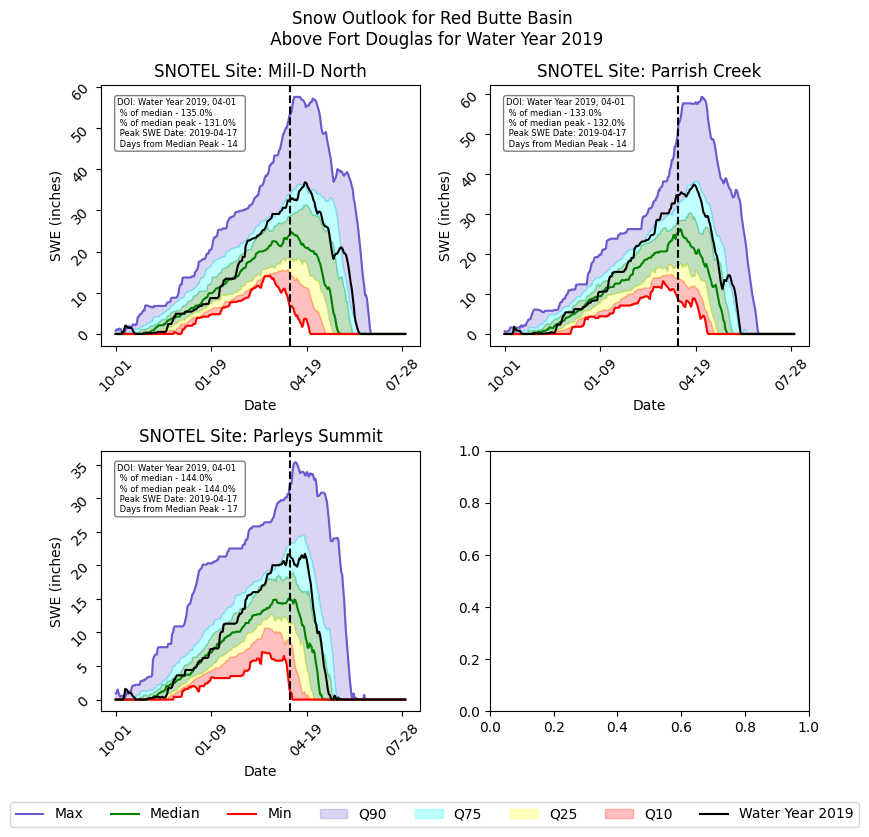

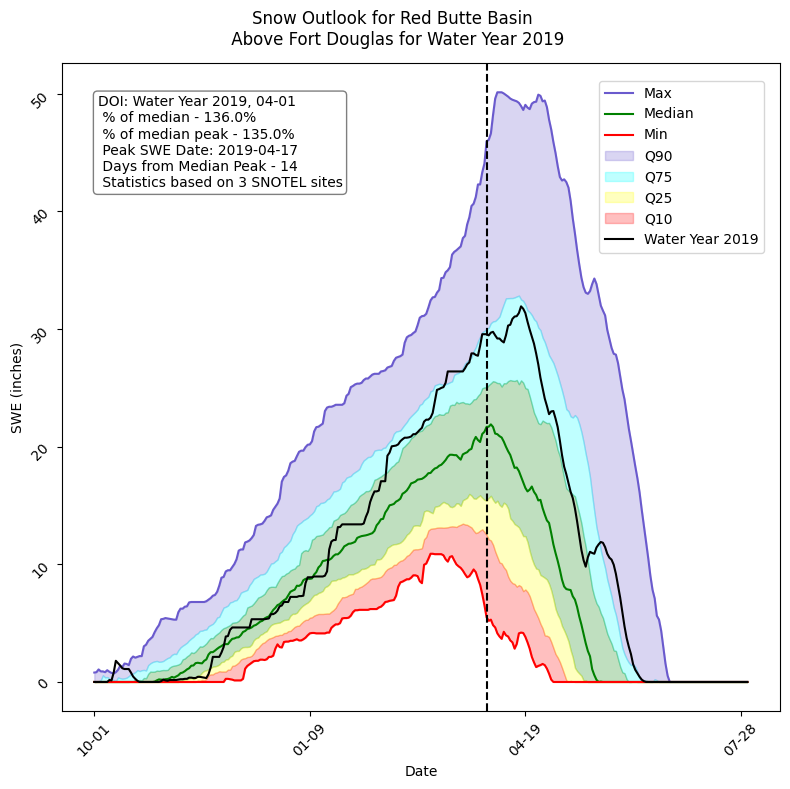

In [16]:
SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_aoi, WY, WATERSHED, AOI_NAME, DOI)
SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, WATERSHED, AOI_NAME, DOI)

## 5) Sanity-check summary (non-zero SWE evidence)

In [7]:
summary_rows = []
for site, df_site in sitedict.items():
    stats = df_site[["min", "median", "max"]].copy()
    summary_rows.append({
        "site": site,
        "non_zero_days_max_gt0": int((stats["max"] > 0).sum()),
        "max_swe_in": round(float(stats["max"].max()), 2),
        "median_peak_in": round(float(stats["median"].max()), 2),
    })

pd.DataFrame(summary_rows).sort_values("max_swe_in", ascending=False)

,site,non_zero_days_max_gt0,max_swe_in,median_peak_in
1,971,266,59.2,26.20
0,628,267,57.5,24.70
2,684,253,35.3,15.05
